### Notebook 05: Interpretabilidad del modelo

### SHAP y LIME sobre la Regresión Logística

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shap
import lime
import lime.lime_tabular

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# --- Rutas ancladas ---
RUTA_BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
RUTA_SHAP = os.path.join(RUTA_BASE, 'reports', 'shap')
os.makedirs(RUTA_SHAP, exist_ok=True)

In [2]:
# --- Carga del dataset limpio ---
df = pd.read_csv(os.path.join(RUTA_BASE, 'data', 'processed', 'ibm_hr_clean.csv'))

# --- One-hot encoding --- 
ibm_encoded = pd.get_dummies(df, drop_first=True)
X = ibm_encoded.drop(columns=['Attrition'])
y = ibm_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# --- Reentrenamiento del modelo ganador ---
modelo_lr = Pipeline([
    ('escalado', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced',
                              max_iter=200, random_state=42))
])
modelo_lr.fit(X_train, y_train)

# --- Verificacion de consistencia ---
print("Test:", X_test.shape[0], "filas |", X.shape[1], "columnas")

Test: 441 filas | 44 columnas


## SHAP

In [3]:
# --- Extracción de scaler y modelo del pipeline ---
scaler = modelo_lr.named_steps['escalado']
lr_modelo = modelo_lr.named_steps['lr']

X_test_escalado = scaler.transform(X_test)
X_test_escalado = pd.DataFrame(X_test_escalado, columns=X_test.columns,
                               index=X_test.index)

# --- SHAP ---
masker = shap.maskers.Independent(X_test_escalado, max_samples=441)
explainer = shap.LinearExplainer(lr_modelo, masker)
shap_values = explainer(X_test_escalado)   

print("Valores SHAP calculados:", shap_values.shape) 

Valores SHAP calculados: (441, 44)


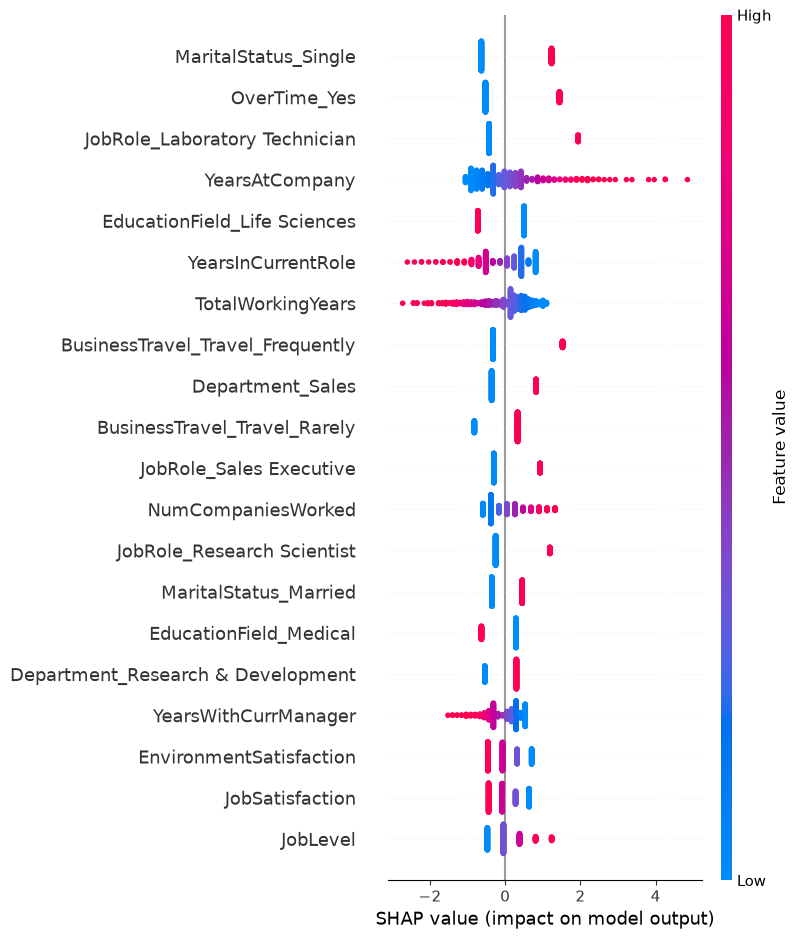

In [4]:
# --- Importancia de cada variable ---
shap.summary_plot(shap_values, X_test_escalado, show=False)
plt.savefig(os.path.join(RUTA_SHAP, 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Coeficientes del LR para validar semejanza con el Summary Plot
coeficientes = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': lr_modelo.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

print(coeficientes.head(15))

                            variable  coeficiente
34     JobRole_Laboratory Technician     0.897020
19                    YearsAtCompany     0.894846
43                      OverTime_Yes     0.893123
42              MaritalStatus_Single     0.864035
16                 TotalWorkingYears    -0.750754
23  BusinessTravel_Travel_Frequently     0.731136
20                YearsInCurrentRole    -0.693101
27      EducationField_Life Sciences    -0.606041
40      JobRole_Sales Representative     0.603205
38        JobRole_Research Scientist     0.585271
26                  Department_Sales     0.541841
11                NumCompaniesWorked     0.534321
24      BusinessTravel_Travel_Rarely     0.523329
33           JobRole_Human Resources     0.512109
39           JobRole_Sales Executive     0.502081


In [6]:
# Tabla de coeficientes
RUTA_TABLES = os.path.join(RUTA_BASE, 'reports', 'tables')
os.makedirs(RUTA_TABLES, exist_ok=True)
coeficientes.to_csv(os.path.join(RUTA_TABLES, 'coeficientes_lr.csv'), index=False)

In [7]:
# Contribuciones locales para modelo lineal (equivalente a SHAP LinearExplainer). Formato largo para Power BI.

RUTA_OUTPUTS = os.path.join(RUTA_BASE, 'outputs')
os.makedirs(RUTA_OUTPUTS, exist_ok=True)

# scaler y modelo_lr extraidos del pipeline
X_test_scaled = scaler.transform(X_test)      # escalar SIN volver a ajustar
coefs = lr_modelo.coef_[0]                     # coeficientes del LR
 
filas = []
for pos, emp_id in enumerate(X_test.index):    # for-loop simple y legible
    for j, feat in enumerate(X_test.columns):
        contrib = coefs[j] * X_test_scaled[pos, j]
        filas.append({
            "employee_id": emp_id,
            "feature": feat,
            "contribucion": contrib
        })
 
shap_local = pd.DataFrame(filas)
shap_local.to_csv(os.path.join(RUTA_OUTPUTS,"shap_local.csv"), index=False)

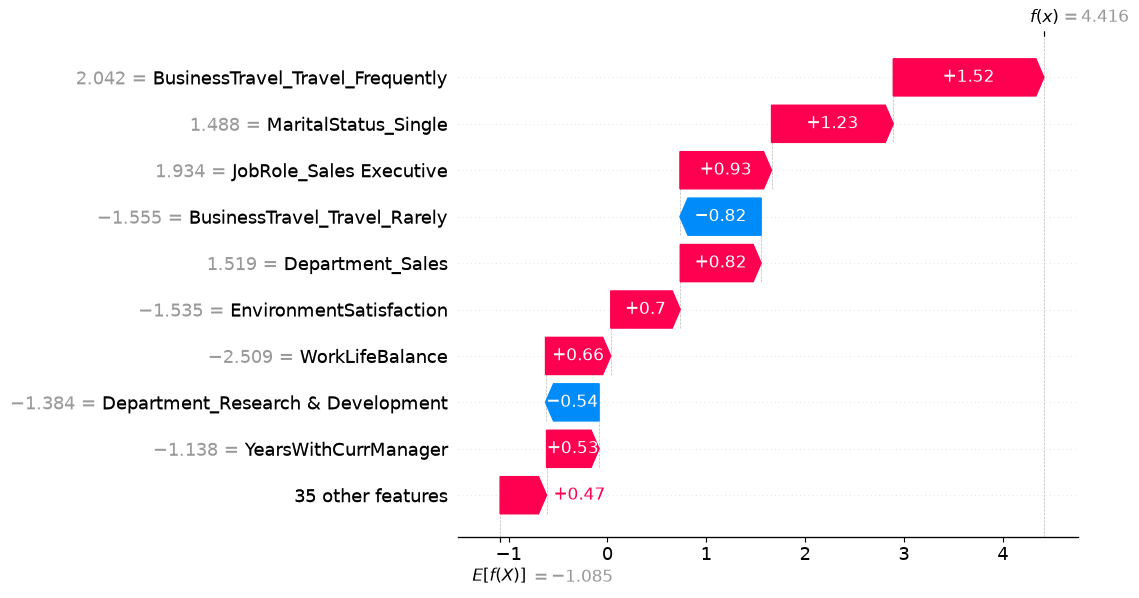

In [8]:
# Ejemplo con empleado alto riesgo de irse
probas = modelo_lr.predict_proba(X_test)[:, 1]
idx_alto = probas.argmax()

shap.plots.waterfall(shap_values[idx_alto], show=False)
plt.savefig(os.path.join(RUTA_SHAP, 'shap_waterfall_alto.png'), dpi=150, bbox_inches='tight')
plt.show()

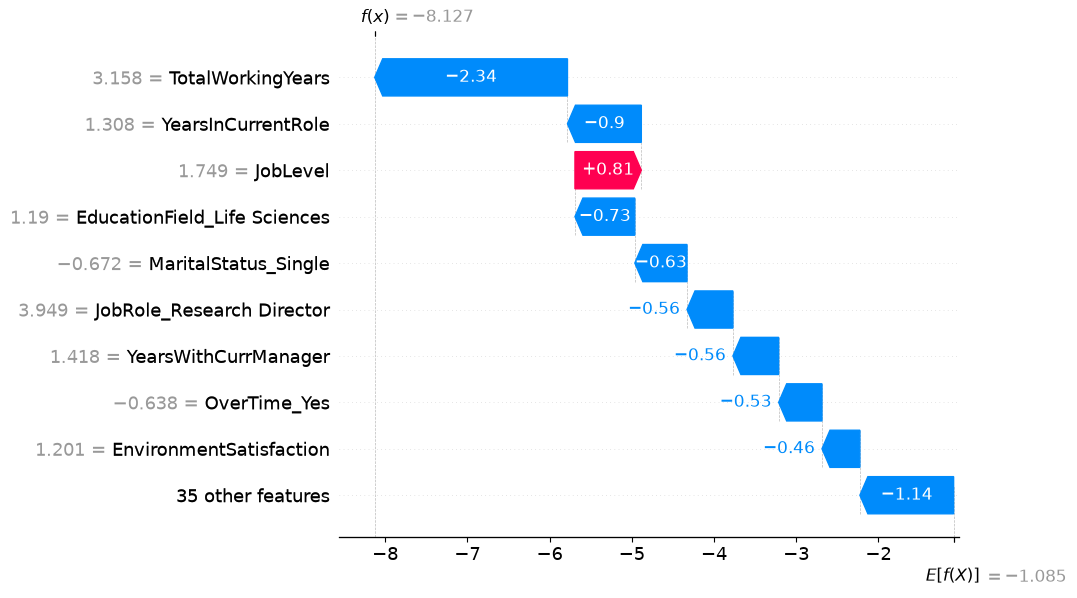

In [9]:
# Empleado con un riesgo bajo de irse
idx_bajo = probas.argmin()   

shap.plots.waterfall(shap_values[idx_bajo], show=False)
plt.savefig(os.path.join(RUTA_SHAP, 'shap_waterfall_bajo.png'), dpi=150, bbox_inches='tight')
plt.show()

Empleado 184 - riesgo de rotacion: 3.22%


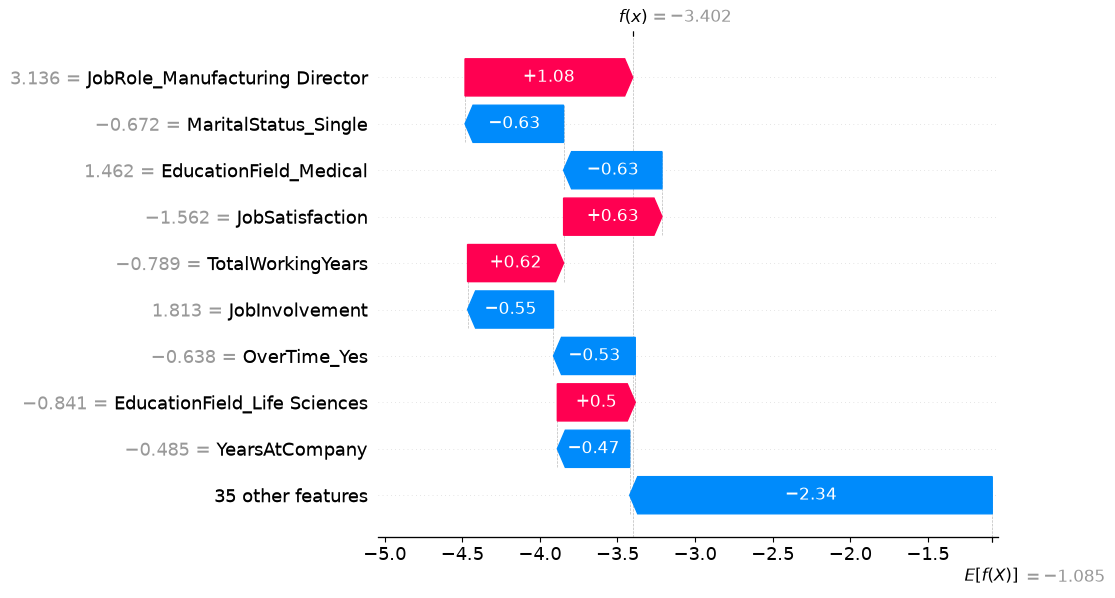

In [10]:
# Función para ver el waterfall de un empleado concreto por su ID, para cuando RRHH quiera revisar un caso especifico
def waterfall_empleado(employee_id):
    # El id del empleado no es lo mismo que su posición en el array, por lo que busco la posición primero
    posicion = X_test.index.get_loc(employee_id)

    # Sacó su probabilidad de riesgo para mostrarla
    score = modelo_lr.predict_proba(X_test)[:, 1][posicion]
    print(f"Empleado {employee_id} - riesgo de rotacion: {score:.2%}")

    # Genero el waterfall de ese empleado
    shap.plots.waterfall(shap_values[posicion], show=False)
    plt.show()

# Ejemplo de empleado
waterfall_empleado(184)

## LIME

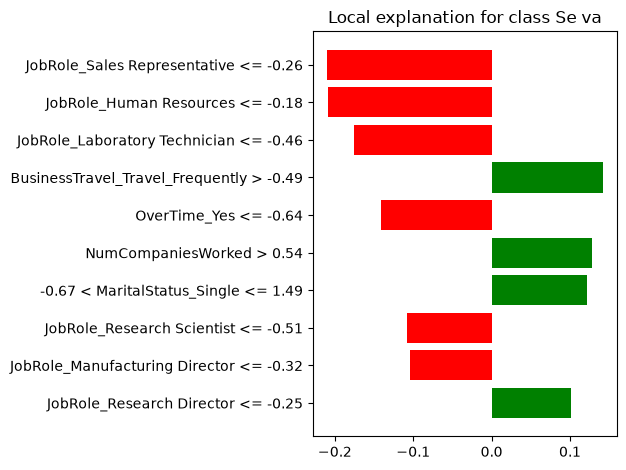

In [11]:
import lime
import lime.lime_tabular

# LIME usa los datos de entrenamiento escalados
X_train_escalado = scaler.transform(X_train)

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_escalado,
    feature_names=X_train.columns.tolist(),
    class_names=['Se queda', 'Se va'],
    mode='classification'
)

# Usamos el mismo empleado con el riesgo alto que vimos con SHAP
idx_alto = probas.argmax()   

exp = explainer_lime.explain_instance(
    X_test_escalado.iloc[idx_alto].values,
    lr_modelo.predict_proba,
    num_features=10
)

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig(os.path.join(RUTA_SHAP, 'lime_empleado_alto.png'), dpi=150, bbox_inches='tight')
plt.show()

## Interpretabilidad del modelo — Conclusiones

El modelo ganardor (Regresión Logística) es interpretable de forma nativa a través de sus coeficientes. Sobre esa base se aplicaron SHAP y LIME para 
añador una forma de comunicación visual para perfiles de RRHH que no son tan técnicos.

-SHAP: El summary plot identifica los principales impulsores de la rotación, como OverTime, YearsAtCompany, MaritalStatus_Single y el rol del empleado,
coherentes con el análisis exploratorio y con los coeficientes del modelo, lo que confirma la consistencia del pipeline. Los waterfall plots 
individuales muestran la predicción de cada empleado, identificandolos mediante el ID, mostrando qué factores elevan o reducen su riesgo y permitiendo
a RRHH una intervención accionable caso por caso.

-LIME: Con este aplicado al mismo empleado de riesgo alto, vemos que coincide con SHAP en los principales factores, reforzando la interpretación con el
uso de dos métodos independientes. LIME presenta mayor dispersión y menor estabilidad entre ejecuciones, por lo que se emplea como apoyo y no como 
método principal.

Como conclusión podemos decir que en un modelo lineal, SHAP converge con los coeficientes, no aporta información adicional, sino una mejor visual
que hace la interpretación más accesible y rápida para perfiles no técnicos. Estas dos formas de mostrar los resultados es el puente entre el modelo y 
la decisión de negocio de RRHH.